# 特徴量の分布の可視化

`dataset/narou_dataset.csv` を読み込み、`train.ipynb`で使われている数値特徴量の分布をヒストグラムと箱ひげ図で確認します。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# 警告を非表示
warnings.filterwarnings('ignore')

In [ ]:
# 日本語フォントの設定 (train.ipynbの指定に合わせる)
try:
    plt.rcParams['font.family'] = 'Meiryo' 
except RuntimeError:
    print("Meiryoフォントが見つかりません。環境に合わせてフォント設定セルを修正してください。")
    # 代替フォントの例 (Windows)
    # plt.rcParams['font.family'] = 'Yu Gothic'
    # 代替フォントの例 (macOS)
    # plt.rcParams['font.family'] = 'Hiragino Sans'

plt.rcParams['axes.unicode_minus'] = False # マイナス記号の文字化けを防ぐ

# Seabornのスタイル設定
sns.set(style='whitegrid', font=plt.rcParams['font.family'])

In [3]:
# データのファイルパス
file_path = 'dataset/narou_dataset.csv'

try:
    # '初回投稿日'と'最終更新日'をdatetime型として読み込む
    df = pd.read_csv(file_path, parse_dates=['初回投稿日', '最終更新日'])
    print(f"'{file_path}' の読み込みに成功しました。")
except FileNotFoundError:
    print(f"エラー: '{file_path}' が見つかりません。")
    print("ファイルパスが正しいか、CSVファイルが実行環境からアクセス可能な場所にあるか確認してください。")
    df = pd.DataFrame() # エラー時も続行できるよう空のDFを作成

'dataset/narou_dataset.csv' の読み込みに成功しました。


In [4]:
# train.ipynbで行われていると想定される特徴量エンジニアリングを再現
if not df.empty:
    print("\n特徴量エンジニアリングを開始します...")
    
    # 1. 年月特徴量の作成 (YYYYMMの数値)
    df['初回投稿年月'] = df['初回投稿日'].dt.year * 100 + df['初回投稿日'].dt.month
    df['最終更新年月'] = df['最終更新日'].dt.year * 100 + df['最終更新日'].dt.month

    # 2. 更新頻度の作成
    # 掲載期間（日数）を計算 (最小1日とする)
    total_duration_days = (df['最終更新日'] - df['初回投稿日']).dt.total_seconds() / (60 * 60 * 24)
    total_duration_days = total_duration_days.apply(lambda x: max(x, 1.0))

    # 投稿話数 (0話の場合を1に補正して0除算を避ける)
    episodes_safe = df['投稿話数'].replace(0, 1)

    # 1話あたりの日数
    df['更新頻度_日数/話'] = total_duration_days / episodes_safe

    print("特徴量エンジニアリング完了。")
    print(df[['初回投稿年月', '最終更新年月', '更新頻度_日数/話']].head())

    print("\nプロット用に日付データを月単位（1日）に丸めます...")
    # .dt.to_period('M') で「年月」情報にし、.dt.to_timestamp() で datetime 型 (その月の1日) に戻す
    df['初回投稿年月_dt'] = df['初回投稿日'].dt.to_period('M').dt.to_timestamp()
    df['最終更新年月_dt'] = df['最終更新日'].dt.to_period('M').dt.to_timestamp()
    print("プロット用の日付データ:")
    print(df[['初回投稿年月_dt', '最終更新年月_dt']].head())
    # --- ▲ ここまで追加 ▲ ---

else:
    print("\nデータが空のため、特徴量エンジニアリングをスキップします。")


特徴量エンジニアリングを開始します...
特徴量エンジニアリング完了。
   初回投稿年月  最終更新年月  更新頻度_日数/話
0  200408  200502  40.262564
1  200406  200406   1.000000
2  202302  202306  13.561076
3  202302  202302   0.125000
4  202301  202301   0.357180

プロット用に日付データを月単位（1日）に丸めます...
プロット用の日付データ:
   初回投稿年月_dt  最終更新年月_dt
0 2004-08-01 2005-02-01
1 2004-06-01 2004-06-01
2 2023-02-01 2023-06-01
3 2023-02-01 2023-02-01
4 2023-01-01 2023-01-01


In [5]:
# 分析対象の特徴量リスト
features_to_plot = [
    '投稿話数', '文字数', '読了時間', '日間ポイント', '週間ポイント', 
    '月間ポイント', '四半期ポイント', '年間ポイント', 'ブックマーク数', '感想数', 
    'レビュー数', '総合評価ポイント', '評価者数', '会話率', '更新頻度_日数/話',
    '初回投稿年月', '最終更新年月'
]

# データの歪みが大きいと予想される特徴量（対数変換してプロット）
skewed_features = [
    '投稿話数', '文字数', '読了時間', '日間ポイント', '週間ポイント', 
    '月間ポイント', '四半期ポイント', '年間ポイント', 'ブックマーク数', '感想数', 
    'レビュー数', '総合評価ポイント', '評価者数', '更新頻度_日数/話'
]

# 歪みが小さい、または対数変換が不適切な特徴量
other_features = [
    '会話率' # '初回投稿年月', '最終更新年月' を削除
]

# 日付型としてプロットする特徴量
datetime_features = [
    '初回投稿年月_dt', '最終更新年月_dt'
]

# dfにカラムが存在するかチェック
if not df.empty:
    # --- ▼ ここから修正 ▼ ---
    # チェック対象のリストを更新
    all_features_to_check = skewed_features + other_features + datetime_features
    missing_cols = [col for col in all_features_to_check if col not in df.columns]
    # --- ▲ ここまで修正 ▲ ---
    
    if missing_cols:
        print(f"警告: 以下の特徴量がデータフレームに存在しません: {missing_cols}")
        # 存在しないカラムをリストから除外
        skewed_features = [col for col in skewed_features if col in df.columns]
        other_features = [col for col in other_features if col in df.columns]
        # --- ▼ ここから追加 ▼ ---
        datetime_features = [col for col in datetime_features if col in df.columns]
        # --- ▲ ここまで追加 ▲ ---
    else:
        print("\nすべての特徴量が揃っています。プロットを開始します。")


すべての特徴量が揃っています。プロットを開始します。


## 1. ヒストグラム（分布の確認）

多くの特徴量は0に集中し、一部に極端に大きな値がある「ロングテール」分布をしています。
そのため、`np.log1p` ( $log(1+x)$ ) を適用して対数変換し、分布の形状を見やすくします。

歪んだ特徴量 (log1p変換) のヒストグラムを作成中...


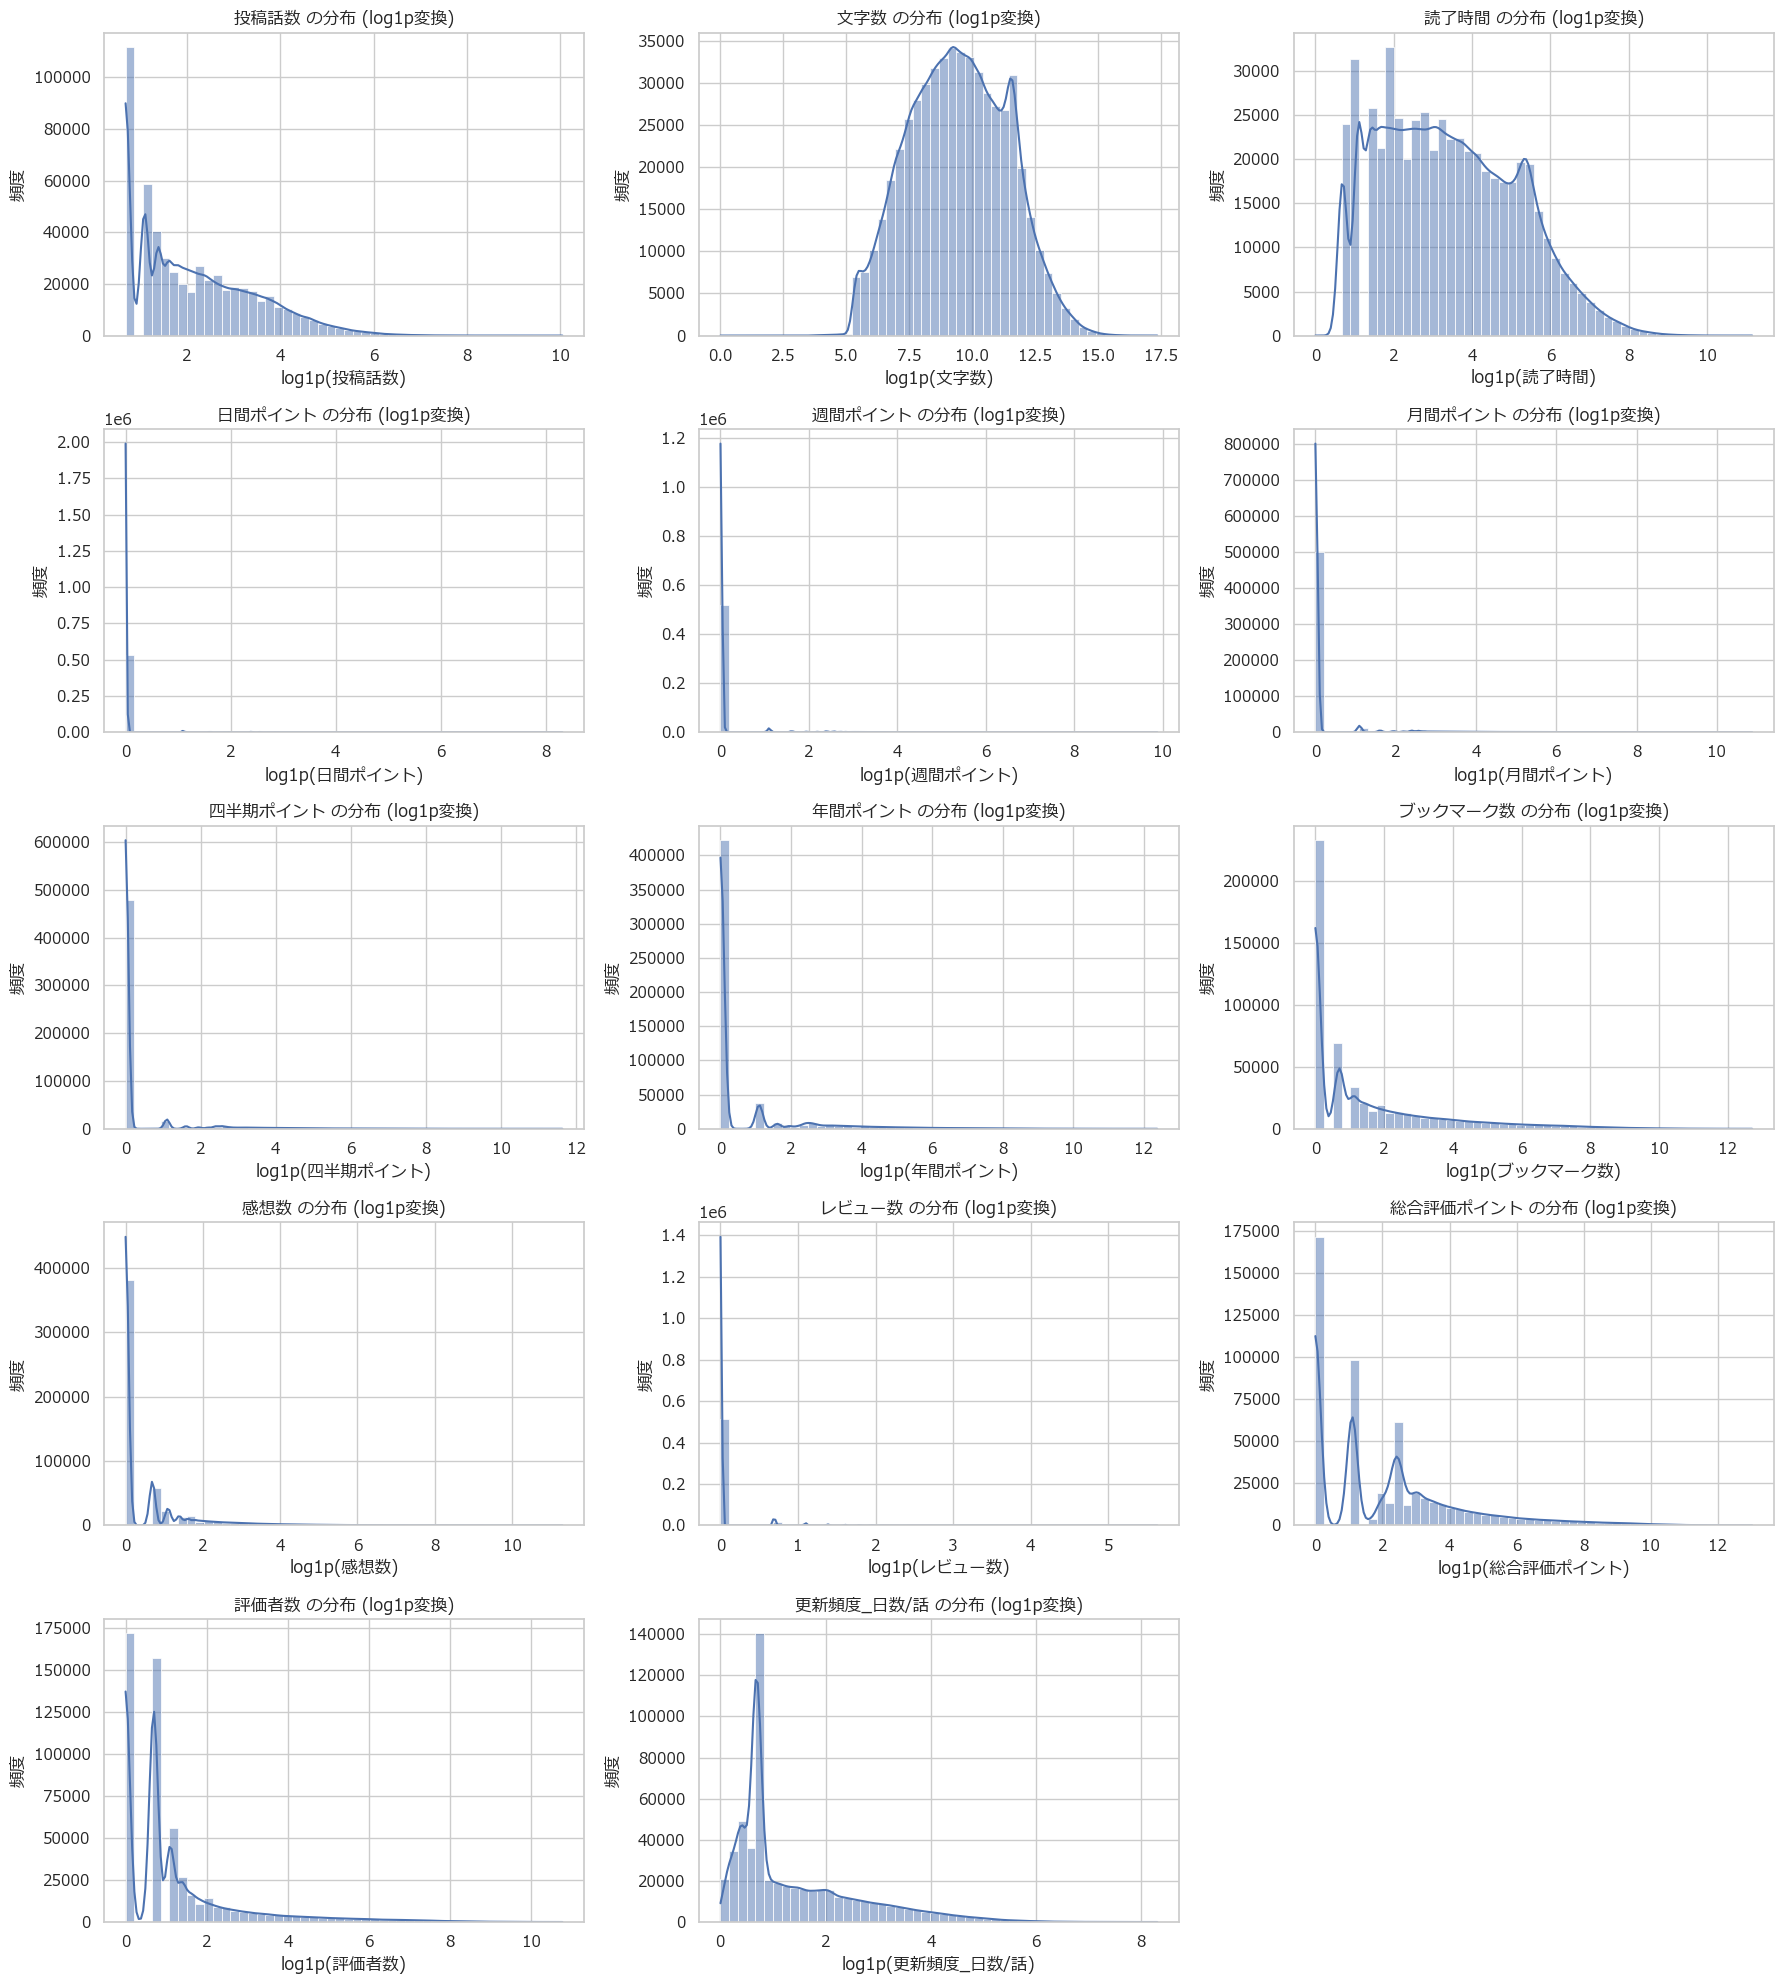

In [6]:
# 歪んだ特徴量 (log1p変換) のヒストグラム
if not df.empty and skewed_features:
    print("歪んだ特徴量 (log1p変換) のヒストグラムを作成中...")
    n_features = len(skewed_features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 4))
    axes = axes.flatten()

    for i, feature in enumerate(skewed_features):
        # np.log1p(x) = np.log(1 + x) を使用し、0の値にも対応
        log_data = np.log1p(df[feature])
        sns.histplot(log_data, ax=axes[i], bins=50, kde=True)
        axes[i].set_title(f'{feature} の分布 (log1p変換)')
        axes[i].set_xlabel(f'log1p({feature})')
        axes[i].set_ylabel('頻度')

    # 余分なサブプロットを非表示
    for i in range(n_features, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()
elif df.empty:
    print("データが空のため、ヒストグラム（歪）をスキップします。")


会話率および日付型特徴量のヒストグラムを作成中...


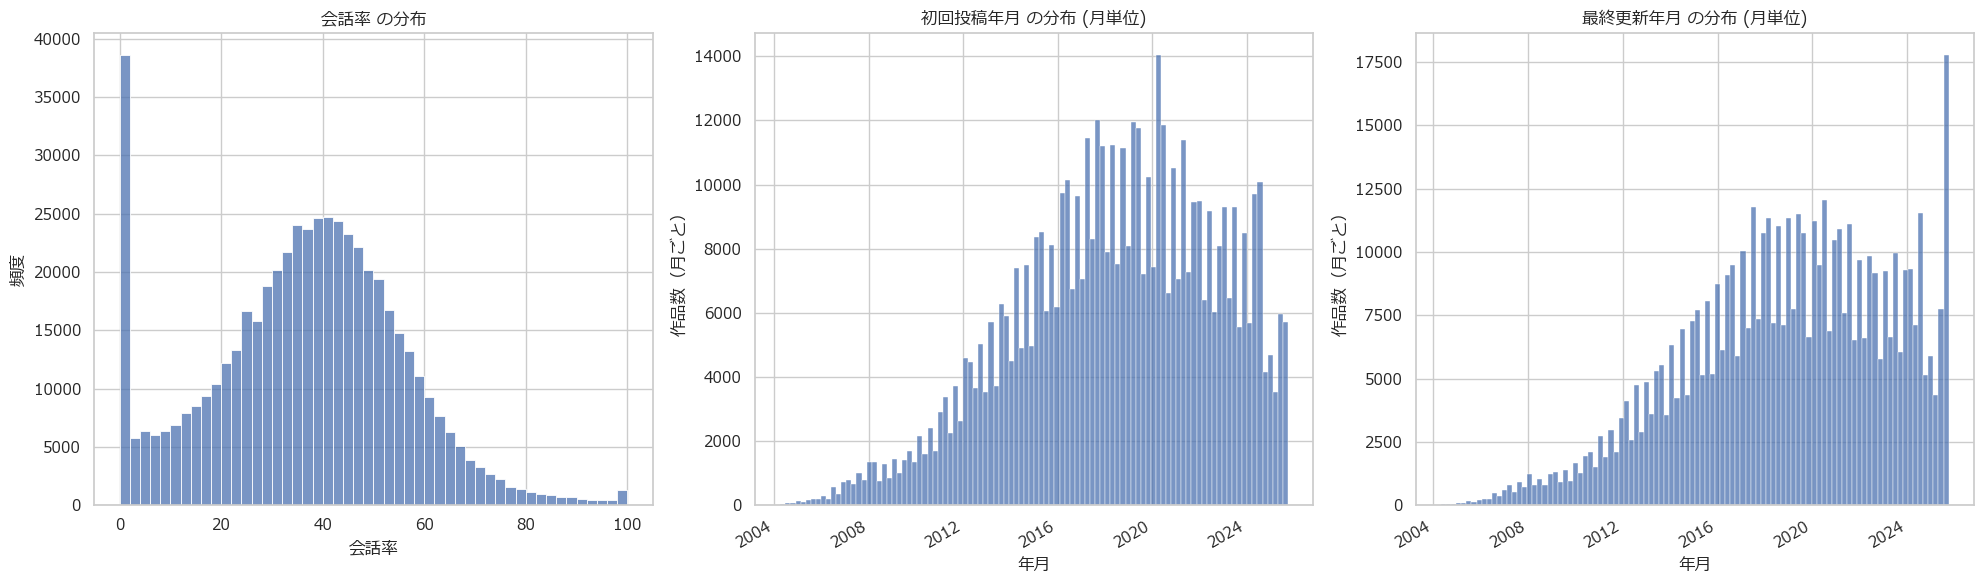

In [7]:
# 会話率・初回投稿年月・最終更新年月のヒストグラムを横並びで表示
if not df.empty and ('会話率' in other_features or datetime_features):
    print("\n会話率および日付型特徴量のヒストグラムを作成中...")
    
    # 1行3列のグラフ領域を作成
    fig, axes = plt.subplots(1, 3, figsize=(20, 6)) # 横幅を広めに設定
    
    # --- 1. 会話率 (axes[0]) ---
    if '会話率' in other_features:
        feature = '会話率'
        sns.histplot(df[feature], ax=axes[0], bins=50, kde=False)
        axes[0].set_title(f'{feature} の分布')
        axes[0].set_xlabel(feature)
        axes[0].set_ylabel('頻度')
    else:
        # プロット対象がない場合、枠を非表示
        axes[0].axis('off') 

    # --- 2. 初回投稿年月 (axes[1]) ---
    if '初回投稿年月_dt' in datetime_features:
        feature = '初回投稿年月_dt'
        sns.histplot(data=df, x=feature, ax=axes[1], bins=100)
        axes[1].set_title(f'{feature.replace("_dt", "")} の分布 (月単位)')
        axes[1].set_xlabel('年月')
        axes[1].set_ylabel('作品数（月ごと）')
        # X軸のラベルを回転
        plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')
    else:
        # プロット対象がない場合、枠を非表示
        axes[1].axis('off') 

    # --- 3. 最終更新年月 (axes[2]) ---
    if '最終更新年月_dt' in datetime_features:
        feature = '最終更新年月_dt'
        sns.histplot(data=df, x=feature, ax=axes[2], bins=100)
        axes[2].set_title(f'{feature.replace("_dt", "")} の分布 (月単位)')
        axes[2].set_xlabel('年月')
        axes[2].set_ylabel('作品数（月ごと）')
        # X軸のラベルを回転
        plt.setp(axes[2].get_xticklabels(), rotation=30, ha='right')
    else:
        # プロット対象がない場合、枠を非表示
        axes[2].axis('off') 

    plt.tight_layout()
    plt.show()

elif df.empty:
    print("データが空のため、ヒストグラム（他・日付型）をスキップします。")

## 2. 箱ひげ図（外れ値の確認）

ヒストグラムと同様に、歪んだ特徴量は `np.log1p` で対数変換してからプロットし、外れ値の様子を分かりやすくします。

歪んだ特徴量 (log1p変換) の箱ひげ図を作成中...


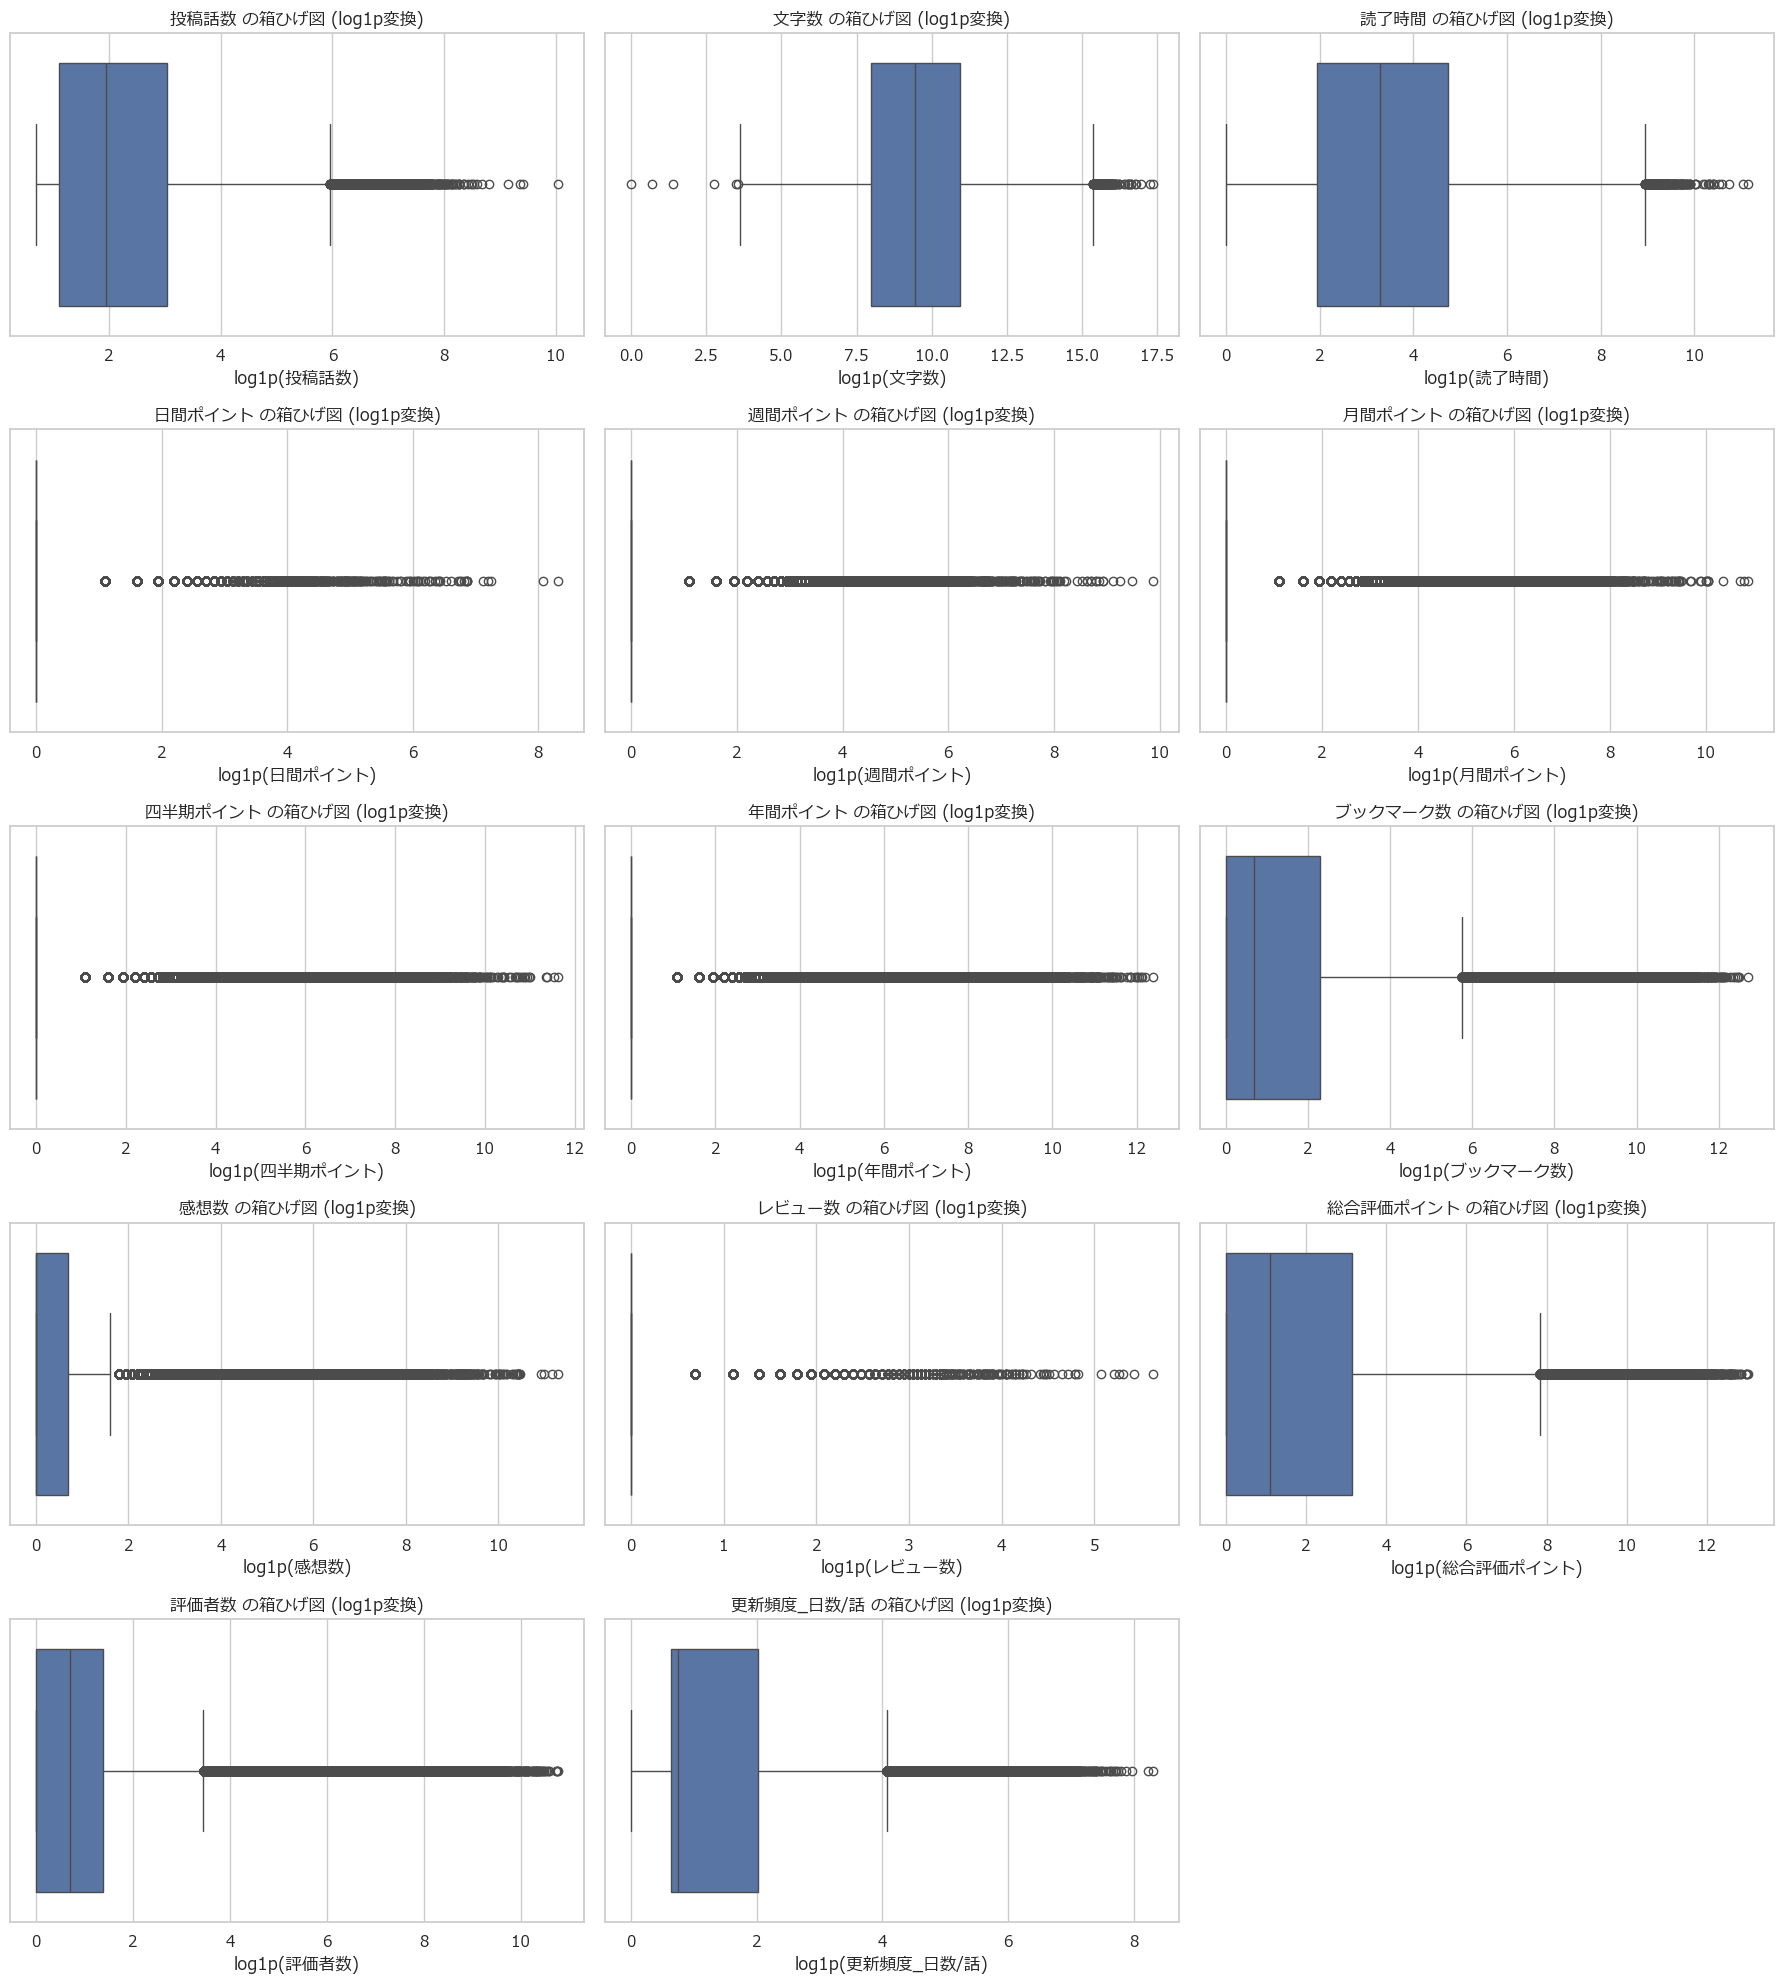

In [8]:
# 歪んだ特徴量 (log1p変換) の箱ひげ図
if not df.empty and skewed_features:
    print("歪んだ特徴量 (log1p変換) の箱ひげ図を作成中...")
    n_features = len(skewed_features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 4))
    axes = axes.flatten()

    for i, feature in enumerate(skewed_features):
        log_data = np.log1p(df[feature])
        sns.boxplot(x=log_data, ax=axes[i])
        axes[i].set_title(f'{feature} の箱ひげ図 (log1p変換)')
        axes[i].set_xlabel(f'log1p({feature})')

    # 余分なサブプロットを非表示
    for i in range(n_features, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()
elif df.empty:
     print("データが空のため、箱ひげ図（歪）をスキップします。")


会話率および日付型特徴量の箱ひげ図を作成中...


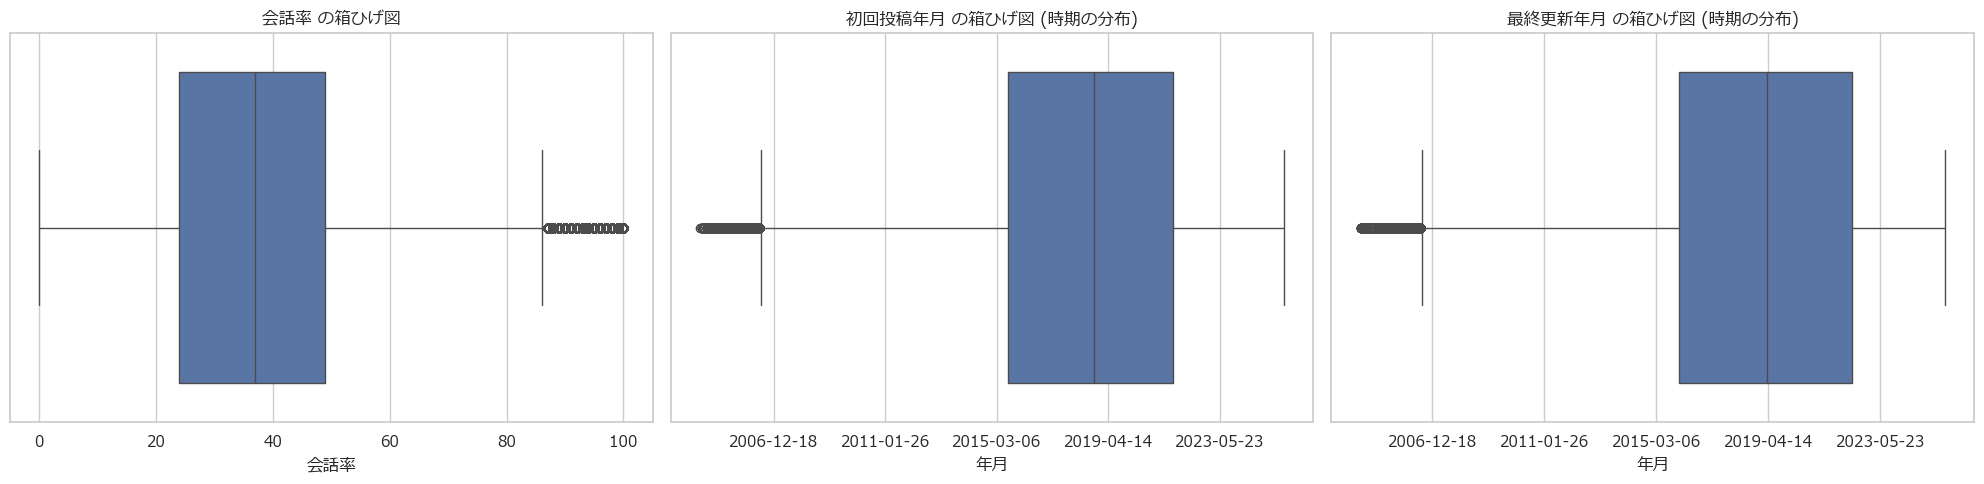

In [9]:
# 会話率・初回投稿年月・最終更新年月の箱ひげ図を横並びで表示
if not df.empty and ('会話率' in other_features or datetime_features):
    print("\n会話率および日付型特徴量の箱ひげ図を作成中...")
    
    # 1行3列のグラフ領域を作成
    fig, axes = plt.subplots(1, 3, figsize=(20, 5)) # 横幅を広めに設定
    
    # --- 1. 会話率 (axes[0]) ---
    if '会話率' in other_features:
        feature = '会話率'
        sns.boxplot(x=df[feature], ax=axes[0])
        axes[0].set_title(f'{feature} の箱ひげ図')
        axes[0].set_xlabel(feature)
    else:
        # プロット対象がない場合、枠を非表示
        axes[0].axis('off') 

    # --- 2. 初回投稿年月 (axes[1]) ---
    if '初回投稿年月_dt' in datetime_features:
        feature = '初回投稿年月_dt'
        sns.boxplot(x=df[feature], ax=axes[1])
        axes[1].set_title(f'{feature.replace("_dt", "")} の箱ひげ図 (時期の分布)')
        axes[1].set_xlabel('年月')
        # X軸のラベルを見やすくするため数を制限
        axes[1].xaxis.set_major_locator(plt.MaxNLocator(6))
    else:
        # プロット対象がない場合、枠を非表示
        axes[1].axis('off') 

    # --- 3. 最終更新年月 (axes[2]) ---
    if '最終更新年月_dt' in datetime_features:
        feature = '最終更新年月_dt'
        sns.boxplot(x=df[feature], ax=axes[2])
        axes[2].set_title(f'{feature.replace("_dt", "")} の箱ひげ図 (時期の分布)')
        axes[2].set_xlabel('年月')
        # X軸のラベルを見やすくするため数を制限
        axes[2].xaxis.set_major_locator(plt.MaxNLocator(6))
    else:
        # プロット対象がない場合、枠を非表示
        axes[2].axis('off') 

    plt.tight_layout()
    plt.show()

elif df.empty:
    print("データが空のため、箱ひげ図（他・日付型）をスキップします。")